# Q1 Population-Sink Static and Oscillating Comparison

This notebook uses the compact-derived fixed-basis population-sink model for `transitions.Q1_F1_1o2_F0`. It compares static exact compact runs to the new population-sink model near the low-field threshold region, then runs the oscillating `0 -> 50 V/cm` case with explicit sink-population tracking.


In [1]:
from importlib.machinery import SourceFileLoader
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid

from centrex_tlf import couplings, states, transitions

runtime_relpath = Path(
    "examples/effective hamiltonian/effective_hamiltonian_runtime.py"
)
repo_root = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / runtime_relpath).exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(runtime_relpath)

ehr = SourceFileLoader("ehr", str(repo_root / runtime_relpath)).load_module()


In [2]:
TRANSITION = transitions.Q1_F1_1o2_F0
OPTICAL_POLARIZATION = couplings.polarization_Z
B_FIELD = (0.0, 0.0, 1e-5)
PATCH_POINTS_VCM = [0.0, 5.0, 7.0, 7.5, 8.0, 10.0, 20.0, 30.0, 40.0, 50.0]
MASTER_FIELD_VCM = 0.0
STATIC_FIELDS_VCM = [0.0, 7.0, 7.5, 8.0, 10.0]

RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0
T_FINAL = 10e-6
N_T = 400
T_EVAL = np.linspace(0.0, T_FINAL, N_T)

OSC_AMPLITUDE_VCM = 25.0
OSC_FREQUENCY_HZ = 100e3
OSC_OMEGA = 2.0 * np.pi * OSC_FREQUENCY_HZ


In [3]:
def compact_bundle(field_vcm: float):
    return ehr.build_compact_reference_decomposed_bundle(
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
        electric_field=(0.0, 0.0, float(field_vcm)),
        magnetic_field=B_FIELD,
    )


def compact_initial_density(system, bundle):
    active_selector = states.QuantumSelector(
        J=int(TRANSITION.J_ground),
        electronic=TRANSITION.electronic_ground,
    )
    active = np.asarray(active_selector.get_indices(system.QN), dtype=np.int64)
    excited = np.asarray(bundle.excited_indices, dtype=np.int64)
    h_opt = np.asarray(bundle.h_opt)
    scores = [float(np.linalg.norm(h_opt[idx, excited])) for idx in active]
    bright_idx = int(active[int(np.argmax(scores))])
    rho0 = np.zeros(
        (bundle.h_internal.shape[0], bundle.h_internal.shape[0]), dtype=np.complex128
    )
    rho0[bright_idx, bright_idx] = 1.0
    return rho0


def compact_photon_rate(solution, bundle):
    jump_rate = np.asarray(bundle.jump_rate_operator())
    dim = bundle.h_internal.shape[0]
    rates = []
    for column in solution.y.T:
        rho = column.reshape(dim, dim)
        rates.append(float(np.real(np.trace(rho @ jump_rate))))
    return np.asarray(rates, dtype=np.float64)


def cumulative_photons(rate: np.ndarray, t_eval: np.ndarray) -> np.ndarray:
    return cumulative_trapezoid(rate, t_eval, initial=0.0)


In [4]:
pop_sink_model = ehr.prepare_population_sink_effective_model(
    field_points=PATCH_POINTS_VCM,
    transition=TRANSITION,
    optical_polarization=OPTICAL_POLARIZATION,
    magnetic_field=B_FIELD,
    master_field=MASTER_FIELD_VCM,
)
(
    pop_sink_model.n_coherent_states,
    pop_sink_model.n_sink_populations,
    pop_sink_model.ground_main_index_p,
    pop_sink_model.sink_labels,
)


(13, 2, 2, ('X, J=0 sink', 'X, J=2 sink'))

In [5]:
static_rows = []
compact_static = {}
pop_sink_static = {}

for field_vcm in STATIC_FIELDS_VCM:
    system, compact_bundle_field = compact_bundle(field_vcm)
    compact_solution = ehr.solve_static_density_matrix_bundle(
        compact_bundle_field,
        rho0=compact_initial_density(system, compact_bundle_field),
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
        method="RK45",
    )
    compact_rate = compact_photon_rate(compact_solution, compact_bundle_field)
    compact_cum = cumulative_photons(compact_rate, T_EVAL)
    compact_static[field_vcm] = {
        "system": system,
        "bundle": compact_bundle_field,
        "solution": compact_solution,
        "rate": compact_rate,
        "cumulative": compact_cum,
    }

    pop_solution = ehr.solve_static_population_sink_model(
        pop_sink_model,
        electric_field=field_vcm,
        y0=ehr.default_population_sink_state(pop_sink_model),
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
        method="RK45",
    )
    pop_rate = ehr.population_sink_scattering_signal(
        pop_sink_model,
        pop_solution,
        electric_field=field_vcm,
    )
    pop_cum = cumulative_photons(pop_rate, T_EVAL)
    pop_sink_traj = ehr.population_sink_populations_trajectory(
        pop_sink_model, pop_solution
    )
    pop_sink_static[field_vcm] = {
        "solution": pop_solution,
        "rate": pop_rate,
        "cumulative": pop_cum,
        "sink_populations": pop_sink_traj,
    }

    static_rows.append(
        {
            "field_vcm": float(field_vcm),
            "photons_compact": float(compact_cum[-1]),
            "photons_population_sink": float(pop_cum[-1]),
            "delta_photons": float(pop_cum[-1] - compact_cum[-1]),
            "rel_delta_photons": float(
                (pop_cum[-1] - compact_cum[-1]) / compact_cum[-1]
            )
            if compact_cum[-1] != 0
            else np.nan,
            **{
                f"final_{label.replace(', ', '_').replace(' ', '_')}": float(
                    np.real(pop_sink_traj[-1, idx])
                )
                for idx, label in enumerate(pop_sink_model.sink_labels)
            },
        }
    )

static_df = pd.DataFrame(static_rows)
static_df


,field_vcm,photons_compact,photons_population_sink,delta_photons,rel_delta_photons,final_X_J=0_sink,final_X_J=2_sink
0,0.0,1.154114,1.154080e+00,-3.413942e-05,-2.958063e-05,0.000000,0.000000
1,7.0,1.154114,-5.196599e+09,-5.196599e+09,-4.502674e+09,0.000000,0.000000
2,7.5,1.160622,1.149847e+00,-1.077500e-02,-9.283811e-03,0.000020,0.000000
3,8.0,1.160833,1.149749e+00,-1.108466e-02,-9.548883e-03,0.000023,0.000011
4,10.0,1.164756,1.147546e+00,-1.721010e-02,-1.477572e-02,0.000036,0.000018


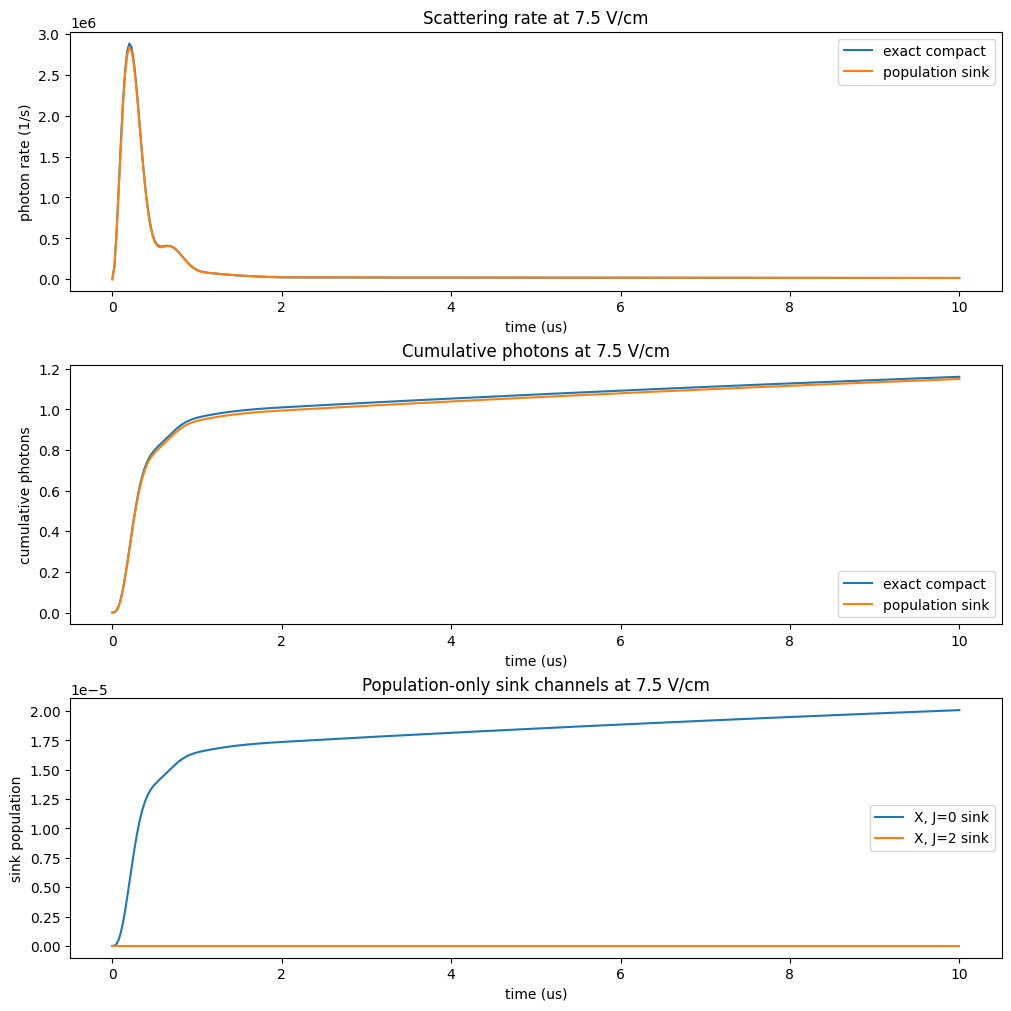

In [6]:
FIELD_TO_PLOT = 7.5

fig, axes = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True)
axes[0].plot(1e6 * T_EVAL, compact_static[FIELD_TO_PLOT]["rate"], label="exact compact")
axes[0].plot(
    1e6 * T_EVAL, pop_sink_static[FIELD_TO_PLOT]["rate"], label="population sink"
)
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("photon rate (1/s)")
axes[0].set_title(f"Scattering rate at {FIELD_TO_PLOT:g} V/cm")
axes[0].legend()

axes[1].plot(
    1e6 * T_EVAL, compact_static[FIELD_TO_PLOT]["cumulative"], label="exact compact"
)
axes[1].plot(
    1e6 * T_EVAL, pop_sink_static[FIELD_TO_PLOT]["cumulative"], label="population sink"
)
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("cumulative photons")
axes[1].set_title(f"Cumulative photons at {FIELD_TO_PLOT:g} V/cm")
axes[1].legend()

for sink_index, sink_label in enumerate(pop_sink_model.sink_labels):
    axes[2].plot(
        1e6 * T_EVAL,
        np.real(pop_sink_static[FIELD_TO_PLOT]["sink_populations"][:, sink_index]),
        label=sink_label,
    )
axes[2].set_xlabel("time (us)")
axes[2].set_ylabel("sink population")
axes[2].set_title(f"Population-only sink channels at {FIELD_TO_PLOT:g} V/cm")
axes[2].legend()

plt.show()


In [7]:
def oscillating_field(t: float):
    return (0.0, 0.0, OSC_AMPLITUDE_VCM * (1.0 - np.cos(OSC_OMEGA * t)))


static_compact_0 = compact_static[0.0]
static_pop_sink_0 = pop_sink_static[0.0]

osc_solution = ehr.solve_population_sink_model(
    pop_sink_model,
    electric_field=oscillating_field,
    y0=ehr.default_population_sink_state(pop_sink_model),
    t_span=(0.0, T_FINAL),
    rabi_rate=RABI_RATE,
    detuning=DETUNING,
    t_eval=T_EVAL,
    method="RK45",
)
osc_rate = ehr.population_sink_scattering_signal(
    pop_sink_model,
    osc_solution,
    electric_field=oscillating_field,
)
osc_cumulative = cumulative_photons(osc_rate, T_EVAL)
osc_sink_populations = ehr.population_sink_populations_trajectory(
    pop_sink_model, osc_solution
)

osc_summary = {
    "photons_static_compact_0": float(static_compact_0["cumulative"][-1]),
    "photons_static_population_sink_0": float(static_pop_sink_0["cumulative"][-1]),
    "photons_oscillating_population_sink": float(osc_cumulative[-1]),
    "rel_vs_static_compact_0": float(
        (osc_cumulative[-1] - static_compact_0["cumulative"][-1])
        / static_compact_0["cumulative"][-1]
    ),
    "rel_vs_static_population_sink_0": float(
        (osc_cumulative[-1] - static_pop_sink_0["cumulative"][-1])
        / static_pop_sink_0["cumulative"][-1]
    ),
    **{
        f"final_{label.replace(', ', '_').replace(' ', '_')}": float(
            np.real(osc_sink_populations[-1, idx])
        )
        for idx, label in enumerate(pop_sink_model.sink_labels)
    },
}
osc_summary


{'photons_static_compact_0': 1.1541140190075503,
 'photons_static_population_sink_0': 1.1540798795903418,
 'photons_oscillating_population_sink': 1.0839083251218755,
 'rel_vs_static_compact_0': -0.060830812839485555,
 'rel_vs_static_population_sink_0': -0.060803030803530424,
 'final_X_J=0_sink': 2.584289488135584e-05,
 'final_X_J=2_sink': 1.0191263012437322e-05}

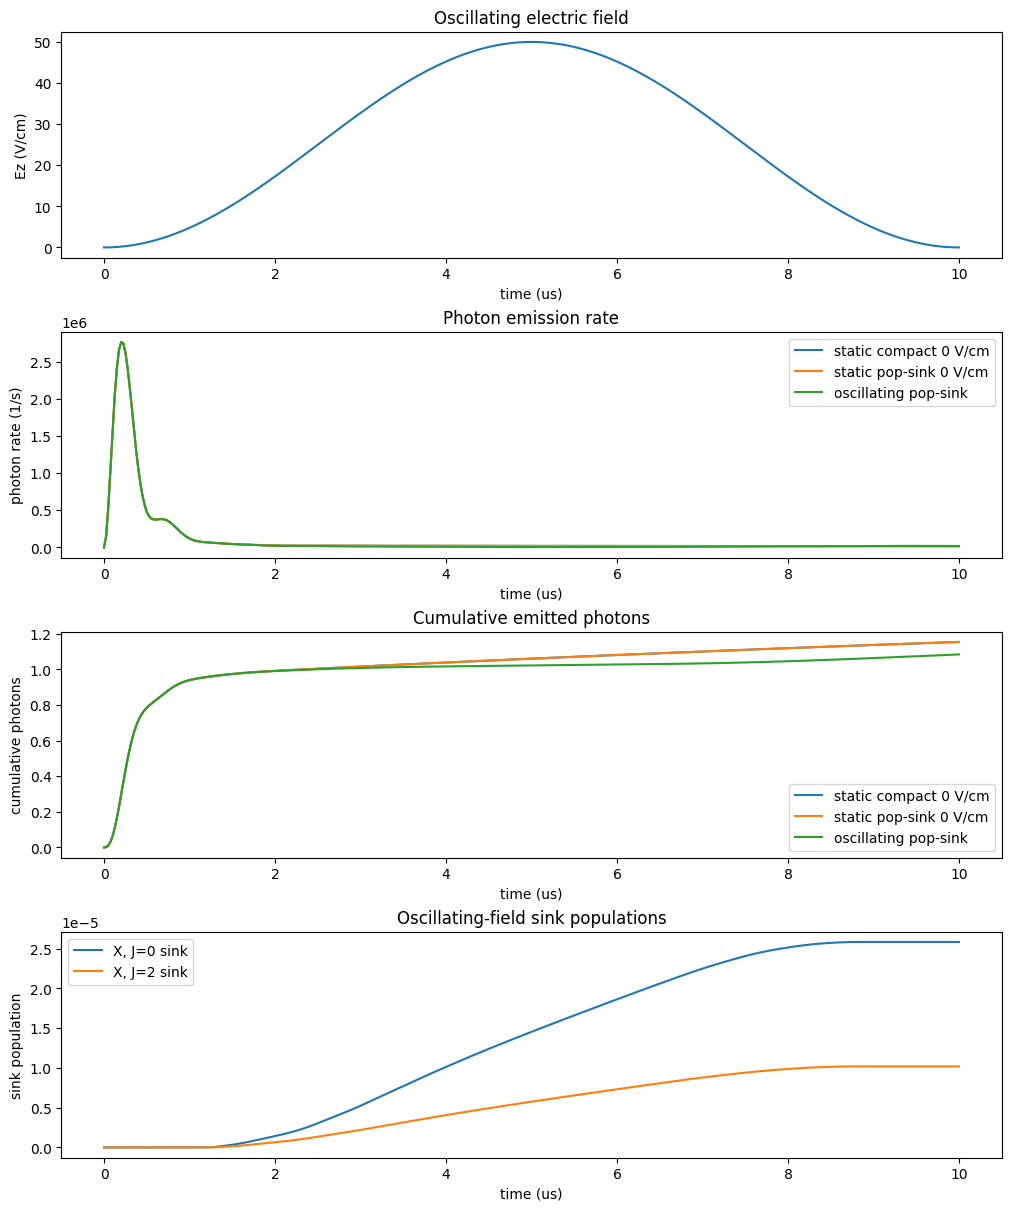

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), constrained_layout=True)
field_trace = np.array([oscillating_field(t)[2] for t in T_EVAL])
axes[0].plot(1e6 * T_EVAL, field_trace)
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("Ez (V/cm)")
axes[0].set_title("Oscillating electric field")

axes[1].plot(1e6 * T_EVAL, static_compact_0["rate"], label="static compact 0 V/cm")
axes[1].plot(1e6 * T_EVAL, static_pop_sink_0["rate"], label="static pop-sink 0 V/cm")
axes[1].plot(1e6 * T_EVAL, osc_rate, label="oscillating pop-sink")
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("photon rate (1/s)")
axes[1].set_title("Photon emission rate")
axes[1].legend()

axes[2].plot(
    1e6 * T_EVAL, static_compact_0["cumulative"], label="static compact 0 V/cm"
)
axes[2].plot(
    1e6 * T_EVAL, static_pop_sink_0["cumulative"], label="static pop-sink 0 V/cm"
)
axes[2].plot(1e6 * T_EVAL, osc_cumulative, label="oscillating pop-sink")
axes[2].set_xlabel("time (us)")
axes[2].set_ylabel("cumulative photons")
axes[2].set_title("Cumulative emitted photons")
axes[2].legend()

for sink_index, sink_label in enumerate(pop_sink_model.sink_labels):
    axes[3].plot(
        1e6 * T_EVAL, np.real(osc_sink_populations[:, sink_index]), label=sink_label
    )
axes[3].set_xlabel("time (us)")
axes[3].set_ylabel("sink population")
axes[3].set_title("Oscillating-field sink populations")
axes[3].legend()

plt.show()
